# Harmonogramowanie zadań z zależnościami i zasobami

* Krzysztof Molenda, 2025.05.30

Kacper Kaszuba

## Problem

Firma produkcyjna potrzebuje harmonogramu wykonania zadań na maszynach, uwzględniającego:

1. zależności między zadaniami (np. zadanie `B` może rozpocząć się dopiero po zakończeniu zadania `A`).
2. ograniczone zasoby (każde zadanie wymaga określonych maszyn, które mogą obsługiwać tylko jedno zadanie naraz).
3. minimalizację całkowitego czasu wykonania (_makespan_).


<div class="alert alert-info">
<b> Definicja Makespan</b><br><br>
Makespan to termin używany w teorii szeregowania zadań do określenia całkowitego czasu trwania wszystkich zadań — czyli czasu od rozpoczęcia pierwszego zadania do zakończenia ostatniego zadania w harmonogramie (najdłuższy czas, po którym wszystkie zadania zostaną wykonane, uwzględniając ich zależności i ograniczenia zasobów).
<br><br>
Formalnie:

$$
\text{makespan} = \max_{1 \leq j \leq n} C_j
$$

gdzie $C_j$ to czas zakończenia zadania $j$, a $n$ to liczba zadań.
</div>



Dane wejściowe: lista zadań, format JSON
```json
[
    {
        "id": "T1",
        "duration": 5,
        "resources": ["Maszyna_A"],
        "dependencies": []  # Zadania, które muszą zakończyć się przed tym zadaniem
    },
    {
        "id": "T2",
        "duration": 3,
        "resources": ["Maszyna_B"],
        "dependencies": ["T1"]
    },
    # ...
]
```

## Cel zadania

**Cel:** opracować harmonogram przypisujący każdemu zadaniu czas startu i zasób, spełniający wszystkie zależności i ograniczenia. Zwrócić makespan (czas zakończenia ostatniego zadania) lub komunikat o niemożliwości rozwiązania.

## Przykład

### Wejście

```python
tasks = [
    {"id": "T1", "duration": 5, "resources": ["M1"], "dependencies": []},
    {"id": "T2", "duration": 3, "resources": ["M1"], "dependencies": ["T1"]},
    {"id": "T3", "duration": 2, "resources": ["M2"], "dependencies": ["T1"]},
    {"id": "T4", "duration": 4, "resources": ["M1"], "dependencies": ["T2", "T3"]}
]
```

### Wyjście

```python
Makespan: 14
T1: 0-5
T2: 5-8
T3: 5-7
T4: 8-12
```

## Rozszerzenia

1. Dodaj obsługę wielu zasobów dla jednego zadania (np. równoczesne użycie 2 maszyn).
2. Zoptymalizuj wybór zasobów, aby minimalizować _makespan_.
3. Zwizualizuj harmonogram za pomocą wykresu Gantta (wygeneruj kod w formacie mermaid (https://mermaid.js.org/syntax/gantt.html)


::::{tip} Demo diagramu Ganta
:class: dropdown

```mermaid
gantt
    title A Gantt Diagram
    dateFormat YYYY-MM-DD
    section Section
        A task          :a1, 2014-01-01, 30d
        Another task    :after a1, 20d
    section Another
        Task in Another :2014-01-12, 12d
        another task    :24d
```
::::

Pracoje w Colab i rozwijane mardowny nie chicały się załadować więc zrobilem ss

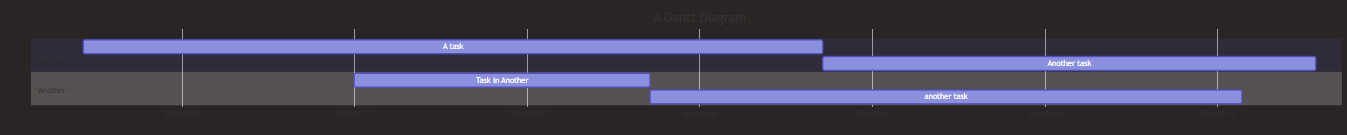

## Rozwiązanie

In [ ]:
# Główne kroki
import json
import networkx as nx

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
import seaborn as sns


{'tasks': [{'id': 'T1',
   'duration': 5,
   'resources': ['M1'],
   'dependencies': []},
  {'id': 'T2', 'duration': 3, 'resources': ['M2'], 'dependencies': ['T1']},
  {'id': 'T3',
   'duration': 2,
   'resources': ['M1', 'M3'],
   'dependencies': ['T1']},
  {'id': 'T4', 'duration': 4, 'resources': ['M2'], 'dependencies': ['T2']},
  {'id': 'T5', 'duration': 6, 'resources': ['M3'], 'dependencies': ['T3']},
  {'id': 'T6',
   'duration': 3,
   'resources': ['M1', 'M2'],
   'dependencies': ['T4', 'T5']},
  {'id': 'T7', 'duration': 5, 'resources': ['M3'], 'dependencies': ['T6']},
  {'id': 'T8', 'duration': 4, 'resources': ['M1'], 'dependencies': ['T7']},
  {'id': 'T9', 'duration': 2, 'resources': ['M2'], 'dependencies': ['T8']},
  {'id': 'T10', 'duration': 3, 'resources': ['M3'], 'dependencies': ['T9']}]}

DiGraph with 10 nodes and 10 edges


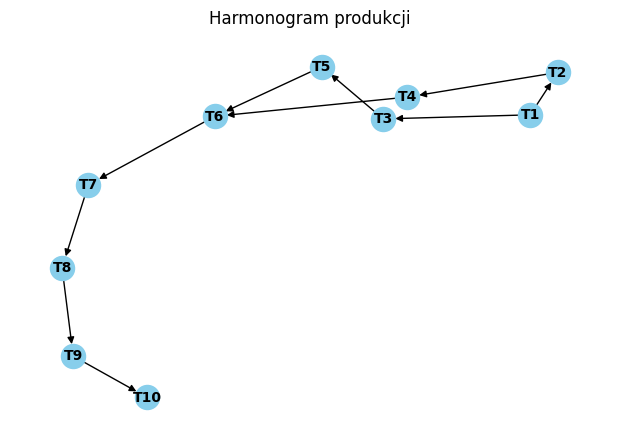

In [ ]:
# 1. Budowa grafu


with open('maszyny.json') as m:
  maszyny =  json.load(m)
display(maszyny)

G = nx.DiGraph()
for task in maszyny['tasks']:
  G.add_node(task["id"],  duration=task['duration'], resources=task['resources'])
  for t in task['dependencies']:
    G.add_edge(t, task["id"])

print(G)

plt.figure(figsize=(6, 4))
nx.draw(G, with_labels=True, node_color='skyblue', font_size=10, font_weight='bold')
plt.title("Harmonogram produkcji")
plt.show()

In [ ]:
# 2. Analiza kolejności
graph_top = list(nx.topological_sort(G))
graph_top

['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10']

In [ ]:
# 3. Harmonogramowanie (scheduling)
task_finish_times = {}
free_m = {}
start_time = {}


for task in graph_top:
  # War 1: kiedy najwczesniej skoncza się zadania od ktorych jest zalezne zadanie
  max_dep_time = 0
  for p in G.predecessors(task):
    max_dep_time = max(max_dep_time, task_finish_times[p])

  # War 2: Kiedy najwczesniej zwolnia się maszyny potrzebne do wykonania zadania
  max_machine_time = 0
  for m in G.nodes[task]['resources']:
    max_machine_time = max(max_machine_time, free_m.get(m, 0))

  real_start = max(max_dep_time, max_machine_time)
  start_time[task] = real_start

  task_finish_times[task] = real_start + G.nodes[task]['duration']

  for m in G.nodes[task]['resources']:
    free_m[m] = task_finish_times[task]


makespan = max(task_finish_times.values())

display(task_finish_times)
display(free_m)
display(makespan)

{'T1': 5,
 'T2': 8,
 'T3': 7,
 'T4': 12,
 'T5': 13,
 'T6': 16,
 'T7': 21,
 'T8': 25,
 'T9': 27,
 'T10': 30}

{'M1': 25, 'M2': 27, 'M3': 30}

30

In [ ]:
# 4. Wizualizacja
print('%%{init: {"gantt": {"displayMode": "compact"}}}%%')
print("gantt")
print("    title Harmonogram produkcji")
print("    dateFormat  X")
print("    axisFormat %s")

seen_tasks = set()

for m in free_m.keys():
    print(f"    section {m}")
    for z in graph_top:
        if m in G.nodes[z]['resources']:
            duration = G.nodes[z]['duration']
            preds = list(G.predecessors(z))

            if len(preds) > 0:
                deps = " ".join(preds)
                timing = f"after {deps}"
            else:
                timing = f"{start_time[z]}"

            if z not in seen_tasks:
                print(f"    {z} : {z}, {timing}, {duration}s")
                seen_tasks.add(z)
            else:
                print(f"    {z} : {timing}, {duration}s")

%%{init: {"gantt": {"displayMode": "compact"}}}%%
gantt
    title Harmonogram produkcji
    dateFormat  X
    axisFormat %s
    section M1
    T1 : T1, 0, 5s
    T3 : T3, after T1, 2s
    T6 : T6, after T4 T5, 3s
    T8 : T8, after T7, 4s
    section M2
    T2 : T2, after T1, 3s
    T4 : T4, after T2, 4s
    T6 : after T4 T5, 3s
    T9 : T9, after T8, 2s
    section M3
    T3 : after T1, 2s
    T5 : T5, after T3, 6s
    T7 : T7, after T6, 5s
    T10 : T10, after T9, 3s


Wynik z Printa powyzszej komórki wklejamy do mermaid.ai

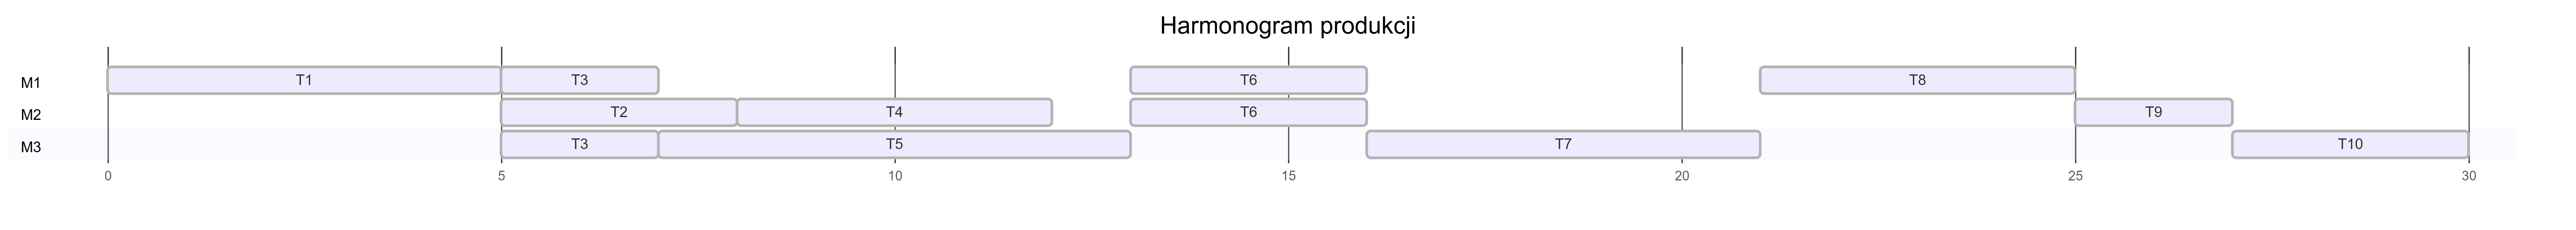

In [ ]:
print(f"Makespan produkcji wynosi: {makespan}")

Makespan produkcji wynosi: 30
